# ORACLE - Stage 4 Generation Pipeline Evaluation
## Phase 4 - Stage 4: Literacy-Conditioned Response Generation

**Purpose:** Evaluate whether gpt-4o-mini generation, conditioned on target literacy band, produces responses at the intended reading level across 4 bands (low, medium, high, clinical).

**Method:** 8 evaluation queries (2 per band) retrieved via Stage 2 pipeline, generated via gpt-4o-mini with band-specific system prompts, scored on Flesch-Kincaid and SMOG.

In [1]:
import sys, os, warnings, logging
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore'); logging.disable(logging.CRITICAL)
from IPython.display import Image
from generation_pipeline import run_stage4

In [2]:
import os
os.chdir('..')  # move to repo root so data paths resolve
results = run_stage4(dry_run=False)
os.chdir('notebooks')
print('Stage 4 generation evaluation complete')

ORACLE, Stage 4: Literacy-Conditioned Response Generation
  Model: gpt-4o-mini
  Mode: LIVE
  Queries: 8
  Top-k retrieval: 5

  Loading DPR encoder...


  Loading DPR query encoder: facebook/dpr-question_encoder-single-nq-base


  DPR encoder ready

  [1/8] Band: low, What is diabetes and how does it affect the body?...


    FK grade: 7.48 | SMOG: 9.39 | Tokens: 555
  [2/8] Band: low, How do I know if I have high blood pressure?...


    FK grade: 4.94 | SMOG: 7.45 | Tokens: 436
  [3/8] Band: medium, What are the treatment options for type 2 diabetes?...


...

    FK grade: 16.1 | SMOG: 17.33 | Tokens: 828
  [6/8] Band: high, How does HbA1c reflect long-term glycemic control?...


    FK grade: 16.97 | SMOG: 17.77 | Tokens: 595
  [7/8] Band: clinical, What are the pharmacokinetics of GLP-1 receptor agonists?...


    FK grade: 16.5 | SMOG: 18.24 | Tokens: 813
  [8/8] Band: clinical, Describe the pathophysiology of diabetic nephropathy....


    FK grade: 16.7 | SMOG: 16.89 | Tokens: 737

  Results saved: /Users/nithinnarla/nithin-research/oracle-rag-pipeline/data/processed/stage4_results.csv


  Figure saved: /Users/nithinnarla/nithin-research/oracle-rag-pipeline/figures/stage4/fk_by_literacy_band.png
  Total tokens used: 5345
  Estimated cost: ~$0.0008

  Readability by literacy band:
    low       : FK=6.2 SMOG=8.4
    medium    : FK=10.4 SMOG=12.2
    high      : FK=16.5 SMOG=17.5
    clinical  : FK=16.6 SMOG=17.6
Stage 4 generation evaluation complete


## 1. FK Grade by Target Literacy Band

Mean Flesch-Kincaid grade of generated responses per target band. A working literacy-conditioned system should show a monotonic increase from low to clinical. This is the core Stage 4 claim for the paper's Results section.

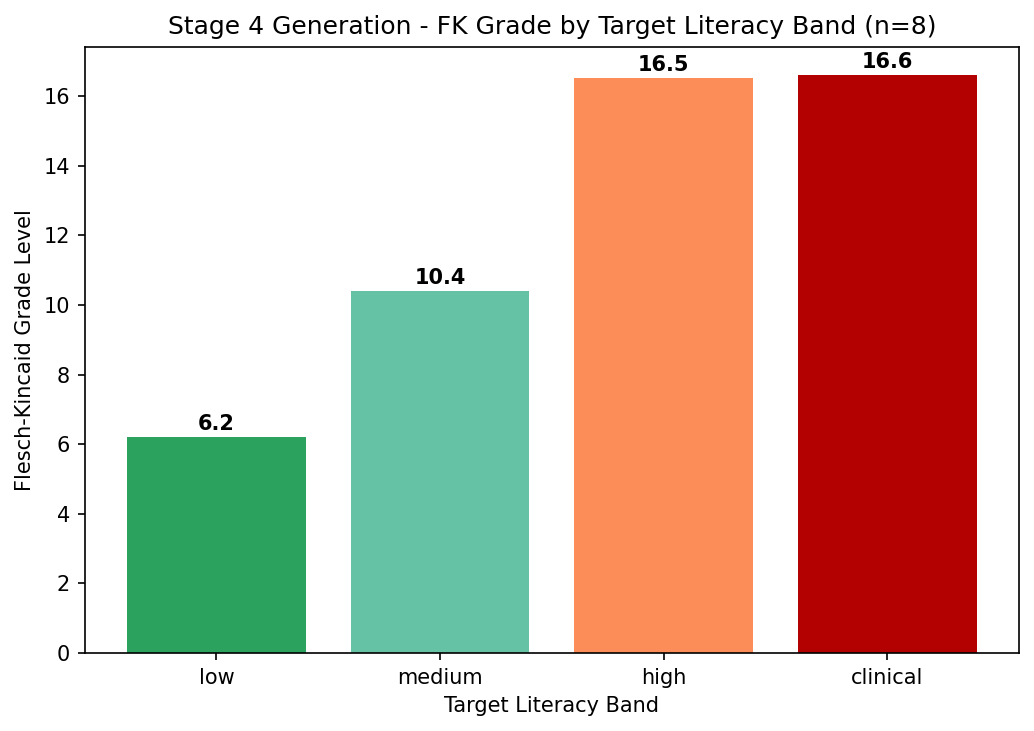

In [3]:
Image('../figures/stage4/fk_by_literacy_band.png')

## 2. Key Findings

**Generation-level literacy conditioning confirmed, retrieval-level conditioning not confirmed.** FK grade increases monotonically across bands (low → medium → high → clinical). This is a real result but a narrower one than it first appears: generation is conditioned on the *target* band passed to the system prompt, not on what was actually retrieved, so this monotonic increase holds even when retrieval fails.

**Retrieval failure case, checked directly (Aug 1):** the FK-based router misclassifies roughly half of queries (4/8 in this eval run). Manually inspecting the misrouted low-band query ('What is diabetes and how does it affect the body?', routed to medium) showed all 5 retrieved documents were MedQA/MIRAGE exam-question fragments , not plain-language content , and one retrieved document was entirely unrelated to diabetes (a sports-psychology multiple-choice question), retrieved only because it happened to score highest within the wrong band's index. This is not a new problem, and it's more precisely documented than a single paraphrase suggests: methodology_decisions.md Decision 10 already accepts, as a named architectural risk, that MedMCQA+MedQA+MIRAGE constitute 93.6% of the corpus and are clinical-professional rather than patient-facing content. Decision 11 independently documents 4/8 (50%) routing accuracy on test queries and specifies that Stage 3 - not Stage 2's FK router - is architecturally responsible for correcting literacy mismatches; routing is explicitly designed as best-effort, not ground truth. What tonight's live check adds on top of that existing documentation: the misrouted query didn't just retrieve wrong-band content, it retrieved one document entirely irrelevant to the query topic (a sports-psychology exam question for a diabetes query) - a retrieval-relevance failure distinct from the literacy-band failure already documented in Decisions 10/11, worth tracking as its own open item.

**What this means for the paper:** the FK-grade-by-band result in the figure above is a valid generation-conditioning result and should be reported as such. It should not be reported, on its own, as evidence that ORACLE's retrieval-level literacy conditioning works , that claim requires either fixing the router/corpus contamination first, or evaluating retrieval quality (e.g. via retrieval_evaluation.py's existing routing-accuracy figures) alongside this generation result, not in place of it.

**Cost:** ~$0.0008 for 8 queries at gpt-4o-mini pricing , full evaluation-set generation is trivially cheap to scale.